## Table of Contents

1. [Introduction](#Introduction)
1. [Data Understanding](#Data-Understanding)
    1. [Data Dictionary](#Data-Dictionary)
        1. [Variable Notes](#Variable-Notes)
    1. [Descriptive Statistics](#Descriptive-Statistics)
    1. [Row Samples](#Row-Samples)
    1. [Data Types](#Data-Types)
    1. [Missing Values Summary](#Missing-Values-Summary)
    1. [Sample Visual Inspection](#Sample-Visual-Inspection)
1. [Feature Engineering](#Feature-Engineering)
1. [Exploratory Data Analysis](#Exploratory-Data-Analysis)
1. [Model Development](#Model-Development)
1. [Final Generalization Test](#Final-Generalization-Test)
1. [Submission File Generation](#Submission-File-Generation)

## Introduction

The sinking of the Titanic is one of the most infamous shipwrecks in history.

On April 15, 1912, during her maiden voyage, the widely considered “unsinkable” RMS Titanic sank after colliding with an iceberg. Unfortunately, there weren’t enough lifeboats for everyone onboard, resulting in the death of 1502 out of 2224 passengers and crew.

While there was some element of luck involved in surviving, it seems some groups of people were more likely to survive than others.

In this challenge, Kaggle asked us to build a predictive model that answers the question: **“What sorts of people were more likely to survive?”** using passenger data (e.g. name, age, gender, socio-economic class, etc).

In [255]:
from datetime import datetime
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import mlflow
import warnings
warnings.filterwarnings(
    "ignore",
    category=UserWarning,
    message=".*Inferred schema contains integer column.*",
    module="mlflow\\.types\\.utils"
)

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

import shap

## Data Understanding

Kaggle provided passenger data split into two files:
* "Training set" (<a href="./input/train.csv">train.csv</a>)
    * 891 rows, 12 features
* "Test set" (<a href="./input/test.csv">test.csv</a>)
    * 418 rows, 11 features (no `Survived` col)

As the "Test set" represents unseen data for use at submission time, I will refrain from loading the data at this time to mitigate data leakage risks.

The Training set is split into the following sets:
* `X_train`: Used to train models, as well as to evaluate model bias.
* `X_train_dev`: Hold out from the Training set used to evaluate model variance and overfitting to training set.
* `X_test`: Hold out from the Training set.  Used to measure final generalization error before generating submission file using Test set.
* `X_val`: Hold out to be created during k-fold cross validation.  After model scores well on `X_train` and `X_train_dev` sets, `X_val` is used to evaluate if there is a distribution mismatch between training and validation sets.  If mismatch observed, probability of mismatch between training and `X_test` (as well as submission Test set) is high.

The `stratify=y` parameter was used to ensure equal distribution of the target variable across training and validation sets.

In [256]:
training_set_df = pd.read_csv('./input/train.csv')
target = 'Survived'

X = training_set_df.drop(columns=target)
y = training_set_df[target]

# Split training data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# Split training set into training and train-dev sets
X_train, X_train_dev, y_train, y_train_dev = train_test_split(X_train, y_train, stratify=y_train, test_size=0.1, random_state=42)

In [257]:
X_train.shape, X_train_dev.shape, X_test.shape

((640, 11), (72, 11), (179, 11))

### Data Dictionary

| Variable | Definition | Key, Example |
| -------- | ---------- | --- |
| **Survived** | Survival | 0 = No, 1 = Yes |
| **PassengerId** | Integer index of passenger | 0,1,2,3,... |
| **Name** | Name of passenger including title | Braund, Mr. Owen Harris |
| **Pclass** | Ticket class | 1 = 1st, 2 = 2nd, 3 = 3rd |
| **Sex** | Sex | female, male |
| **Age** | Age in years | 0.15, 2, 15 |
| **SibSp** | # of siblings / spouses aboard the Titanic | 0,1,2,3,.. |
| **Parch** | # of parents / children aboard the Titanic | 0,1,2,3,.. |
| **Ticket** | Ticket number, some with prefixes, **shared among groups** | SW/PP 751 |
| **Fare** | Passenger fare, **shared among groups**	 | 7.91, 14.4542, 512.3292 |
| **Cabin** | Cabin number(s) listed on ticket, prefixed with deck letter, **shared among groups**	 | A20, "B57 B59 B63 B66"	 |
| **Embarked** | Port of Embarkation | C = Cherbourg (France), Q = Queenstown (Ireland), S = Southampton (England) |

#### Variable Notes

**pclass:** A proxy for socio-economic status (SES)
* 1st = Upper
* 2nd = Middle
* 3rd = Lower

**age:** Age is fractional if less than 1. If the age is estimated, is it in the form of xx.5

**sibsp:** The dataset defines family relations in this way...
* Sibling = brother, sister, stepbrother, stepsister
* Spouse = husband, wife (mistresses and fiancés were ignored)

**parch:** The dataset defines family relations in this way...
* Parent = mother, father
* Child = daughter, son, stepdaughter, stepson
* Some children travelled only with a nanny, therefore parch=0 for them.

### Descriptive Statistics

In [258]:
X_train.describe(include='number')

,PassengerId,Pclass,Age,SibSp,Parch,Fare
count,640.000000,640.000000,521.000000,640.000000,640.000000,640.000000
mean,437.110937,2.310938,29.826142,0.503125,0.396875,31.734980
std,259.100814,0.830863,14.478596,1.083374,0.851395,45.970971
min,1.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,213.750000,2.000000,21.000000,0.000000,0.000000,7.925000
50%,423.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,664.250000,3.000000,39.000000,1.000000,0.000000,30.548950
max,891.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Initial insights:
* **PassengerId:** column is most likely a sequential integer index from 1 to 891
* **Survived:** Mean survival rate for this data set is 38.4%
* **Pclass:** Top 25% of passengers were in 1st and 2nd Class, remainder in 3rd class
* **Age:** Youngest child was less than 6 months old, oldest is 80 years old.  Median age 28 yrs, 75th pecentile 38 yrs.  177 values missing
* **SibSp / Parch**:  At least 50% of passengers traveled alone, 75% passengers had at most 1 sibling or spouse.  Max family size is 8
* **Fare:** Fares ranged from 0.00 (potentially crew?) to 512.32.  Median fare 14.45, 75th percentile 31.00 - highest fares likely correlates with upper class

In [259]:
X_train.describe(include='object')

,Name,Sex,Ticket,Cabin,Embarked
count,640,640,640,144,638
unique,640,2,520,115,3
top,"Coxon, Mr. Daniel",male,S.O.C. 14879,G6,S
freq,1,412,5,4,469


Initial insights:
* **Name:** Contains surname and title info, probable tokens for splitting
* **Sex:** Majority of passengers were male
* **Ticket:** Contains number; some contain prefixes with potentially useful info. 210 passengers shared the same ticket number, indicating traveling together (may be family and/or household staff)
* **Cabin:** Contains room number and deck letter prefix.  Some cabin strings contain multiple cabin numbers, may also signal family or household staff relationships.  687 values missing
* **Embarked:** Majority of passengers embarked from Southampton, England (644).  2 values missing

### Row Samples

In [260]:
X_train.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
94,95,3,"Coxon, Mr. Daniel",male,59.0,0,0,364500,7.2500,NaN,S
766,767,1,"Brewe, Dr. Arthur Jackson",male,NaN,0,0,112379,39.6000,NaN,C
109,110,3,"Moran, Miss. Bertha",female,NaN,1,0,371110,24.1500,NaN,Q
807,808,3,"Pettersson, Miss. Ellen Natalia",female,18.0,0,0,347087,7.7750,NaN,S
189,190,3,"Turcin, Mr. Stjepan",male,36.0,0,0,349247,7.8958,NaN,S


### Data Types

In [261]:
X_train.dtypes

PassengerId      int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

### Missing Values Summary

In [262]:
X_train.isnull().sum().loc[lambda x: x > 0]

Age         119
Cabin       496
Embarked      2
dtype: int64

### Sample Visual Inspection

Visual inspection shows variaion in **ticket prefixes**, **cabin numbers (e.g. multiple numbers)** and **name tokens (e.g. title, multiple names)**.

In [263]:
# Run multiple times to see different samples
X_train.sample(25)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
471,472,3,"Cacic, Mr. Luka",male,38.0,0,0,315089,8.6625,NaN,S
15,16,2,"Hewlett, Mrs. (Mary D Kingcome)",female,55.0,0,0,248706,16.0000,NaN,S
656,657,3,"Radeff, Mr. Alexander",male,NaN,0,0,349223,7.8958,NaN,S
114,115,3,"Attalah, Miss. Malake",female,17.0,0,0,2627,14.4583,NaN,C
782,783,1,"Long, Mr. Milton Clyde",male,29.0,0,0,113501,30.0000,D6,S
761,762,3,"Nirva, Mr. Iisakki Antino Aijo",male,41.0,0,0,SOTON/O2 3101272,7.1250,NaN,S
280,281,3,"Duane, Mr. Frank",male,65.0,0,0,336439,7.7500,NaN,Q
557,558,1,"Robbins, Mr. Victor",male,NaN,0,0,PC 17757,227.5250,NaN,C
253,254,3,"Lobb, Mr. William Arthur",male,30.0,1,0,A/5. 3336,16.1000,NaN,S
14,15,3,"Vestrom, Miss. Hulda Amanda Adolfina",female,14.0,0,0,350406,7.8542,NaN,S


## Feature Engineering

In [264]:
def engineer_features(df):

    # Create Sex_Encoded feature
    df['Sex_Encoded'] = df['Sex'].map({'male': 0, 'female': 1})

    # Create Deck feature from CabinCabin
    df['Deck'] = df['Cabin'].str[0]

    # Fill missing Deck values with 'U' for Unknown
    df['Deck'] = df['Deck'].fillna('U')

    # Create Title feature from Name
    def extract_title(name):
        title = name.split(',')[1].split('.')[0].strip()
        return title
    df['Title'] = df['Name'].apply(extract_title)

    # Create Surname feature from Name
    def extract_surname(name):
        surname = name.split(',')[0].strip()
        return surname
    df['Surname'] = df['Name'].apply(extract_surname)

    # Create Ticket Prefix and Number features from Ticket
    def extract_ticket_info(ticket):
        if pd.isnull(ticket):
            return None, None
        parts = ticket.split()
        prefix = parts[0] if len(parts) > 1 else ''
        number = parts[-1] if len(parts) > 1 else parts[0]
        return prefix, number
    df[['Ticket_Prefix', 'Ticket_Number']] = df['Ticket'].apply(lambda x: pd.Series(extract_ticket_info(x)))

    # Print non-numeric Ticket Numbers in training data with counts
    non_numeric_ticket_numbers = df[~df['Ticket_Number'].str.isnumeric()]['Ticket_Number'].value_counts()
    print("Non-numeric Ticket Numbers in training data:")
    print(non_numeric_ticket_numbers)

    # Set 4 'LINE' Ticket Numbers to -1
    df.loc[df['Ticket_Number'].isin(['LINE']), 'Ticket_Number'] = -1

    # Create Ticket Frequency feature from Ticket Number on training data only
    #ticket_freq_train = X_train['Ticket_Number'].value_counts().to_dict()
    #df['Ticket_Frequency'] = df['Ticket_Number'].map(ticket_freq_train)

    # Calculate Fare per Person
    #df['Fare_Per_Person'] = df['Fare'] / df['Ticket_Frequency']
    #df['Fare_Per_Person_Scaled'] = (df['Fare_Per_Person'] - df['Fare_Per_Person'].mean()) / df['Fare_Per_Person'].std()

    # def bin_ticket_frequency(freq):
    #     if freq < 4:
    #         return freq
    #     else:
    #         return 4
    # df['Ticket_Frequency'] = df['Ticket_Frequency'].apply(bin_ticket_frequency)

    # Create Family Size feature
    df['Family_Size'] = df['SibSp'] + df['Parch'] + 1
    def bin_family_size(size):
        if size < 4:
            return size
        else:
            return 4
    df['Family_Size'] = df['Family_Size'].apply(bin_family_size)

    # Bin Parch and SibSp
    def bin_parch(parch):
        if parch < 3:
            return parch
        else:
            return 3
    df['Parch'] = df['Parch'].apply(bin_parch)

    def bin_sibsp(sibsp):
        if sibsp < 2:
            return sibsp
        else:
            return 2
    df['SibSp'] = df['SibSp'].apply(bin_sibsp)

    # Create Is_Alone feature
    df['Is_Alone'] = (df['Family_Size'] == 1).astype(int)

    # Create Cabin_Count feature from Cabin
    df['Cabin_Count'] = df['Cabin'].apply(lambda x: len(x.split()) if pd.notnull(x) else 0)
    def bin_cabin_count(cabin_count):
        if cabin_count < 2:
            return cabin_count
        else:
            return 2
    df['Cabin_Count'] = df['Cabin_Count'].apply(bin_cabin_count)

    # Create Cabin Number feature
    df['Cabin_Number'] = df['Cabin'].str.extract(r'(\d+)')

    # Create Port or Starboard feature based on Cabin Number
    def cabin_side(cabin_number):
        if pd.isnull(cabin_number):
            return 'Unknown'
        if cabin_number.isdigit():
            return 'Starboard' if int(cabin_number) % 2 == 0 else 'Port'
        return 'Unknown'
    df['Cabin_Side'] = df['Cabin_Number'].apply(cabin_side)

    # Create Cabin_Missing feature
    df['Cabin_Missing'] = df['Cabin'].isnull().astype(int)

    # Fill missing Cabin_Number values with 0
    df['Cabin_Number'] = df['Cabin_Number'].fillna(0).astype(int)

    # Drop original Cabin column
    df.drop(columns=['Cabin'], inplace=True)

    # Create Scaled Fare feature
    df['Fare_Scaled'] = (df['Fare'] - df['Fare'].mean()) / df['Fare'].std()

    # Create Age_Missing feature
    df['Age_Missing'] = df['Age'].isnull().astype(int)

    # Imput missing Age values using median of Pclass/Title gr
    def impute_age(df):

        # First attempt to impute by Pclass X Title
        pclass_title_age_median_map = df.groupby(['Pclass', 'Title'])['Age'].median()
        def impute_age_by_pclass_title(row):
            if pd.notna(row['Age']):
                return row['Age']
            return pclass_title_age_median_map.loc[row['Pclass'], row['Title']]
        df['Age'] = df.apply(impute_age_by_pclass_title, axis=1)

        # In the scenario where all ages for a given title are missing, impute with median age for Sex
        sex_age_median_map = df.groupby(['Sex'])['Age'].median()
        def impute_age_by_sex(row):
            if pd.notna(row['Age']):
                return row['Age']
            return sex_age_median_map.loc[row['Sex']]
        df['Age'] = df.apply(impute_age_by_sex, axis=1)
    impute_age(df)

    df['Is_Child'] = (df['Age'] < 10).astype(int)
    df['Age_Scaled'] = (df['Age'] - df['Age'].mean()) / df['Age'].std()

    return df


In [265]:
X_train = engineer_features(X_train)

Non-numeric Ticket Numbers in training data:
Ticket_Number
LINE    2
Name: count, dtype: int64


In [266]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 640 entries, 94 to 219
Data columns (total 26 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   PassengerId    640 non-null    int64  
 1   Pclass         640 non-null    int64  
 2   Name           640 non-null    object 
 3   Sex            640 non-null    object 
 4   Age            640 non-null    float64
 5   SibSp          640 non-null    int64  
 6   Parch          640 non-null    int64  
 7   Ticket         640 non-null    object 
 8   Fare           640 non-null    float64
 9   Embarked       638 non-null    object 
 10  Sex_Encoded    640 non-null    int64  
 11  Deck           640 non-null    object 
 12  Title          640 non-null    object 
 13  Surname        640 non-null    object 
 14  Ticket_Prefix  640 non-null    object 
 15  Ticket_Number  640 non-null    object 
 16  Family_Size    640 non-null    int64  
 17  Is_Alone       640 non-null    int32  
 18  Cabin_Count   

In [267]:
# Create categorical and numerical feature lists
target = 'Survived'
base_categorical_features = [] # TODO

base_numerical_features = [
    'Sex_Encoded', 'Pclass', 'SibSp', 'Parch', 'Family_Size', 'Cabin_Count',
    'Cabin_Number', 'Fare_Scaled', 'Age_Scaled', 'Is_Alone', 'Is_Child',
    'Cabin_Missing', 'Ticket_Number'
]

In [268]:
def remove_duplicates(X_df, features, y_df=None):
    """ Remove duplicate rows based on specified features. """

    # Combine features and target into a single DataFrame
    if y_df is None:
        y_df = pd.Series([None] * len(X_df), name='Target')
    df = pd.concat([X_df[features], y_df], axis=1)

    # Check for duplicates
    train_duplicates = df[features].duplicated().sum()
    print(f"Number of duplicate rows in train set: {train_duplicates}")

    # Drop duplicates to reduce multicollinearity
    X_df = X_df.drop_duplicates(subset=features)

    # Drop corresponding target values
    y_df = y_df[X_df.index]

    # Check for duplicates
    check_train_duplicates = X_df[features].duplicated().sum()
    print(f"Number of duplicate rows in train set after dropping: {check_train_duplicates}")

In [269]:
remove_duplicates(X_train, base_categorical_features + base_numerical_features, y_train)

Number of duplicate rows in train set: 4
Number of duplicate rows in train set after dropping: 0


In [270]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 640 entries, 94 to 219
Data columns (total 26 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   PassengerId    640 non-null    int64  
 1   Pclass         640 non-null    int64  
 2   Name           640 non-null    object 
 3   Sex            640 non-null    object 
 4   Age            640 non-null    float64
 5   SibSp          640 non-null    int64  
 6   Parch          640 non-null    int64  
 7   Ticket         640 non-null    object 
 8   Fare           640 non-null    float64
 9   Embarked       638 non-null    object 
 10  Sex_Encoded    640 non-null    int64  
 11  Deck           640 non-null    object 
 12  Title          640 non-null    object 
 13  Surname        640 non-null    object 
 14  Ticket_Prefix  640 non-null    object 
 15  Ticket_Number  640 non-null    object 
 16  Family_Size    640 non-null    int64  
 17  Is_Alone       640 non-null    int32  
 18  Cabin_Count   

## Exploratory Data Analysis

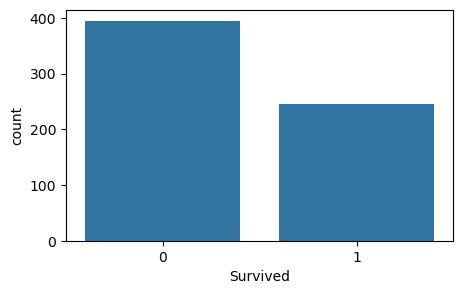

Global Survival Rate: 0.3828
Baseline Accuracy (if predicting majority class): 0.6172


In [271]:
y_df = pd.DataFrame(y_train).reset_index(drop=True)

plt.figure(figsize=(5, 3))
sns.countplot(x='Survived', data=y_df)
plt.show()

global_survival_rate = y_df['Survived'].mean()
print(f"Global Survival Rate: {global_survival_rate:.4f}")
print(f"Baseline Accuracy (if predicting majority class): {max(global_survival_rate, 1 - global_survival_rate):.4f}") 

In [272]:
def plot_corr_heatmap(feature_df, target_series, figsize=(10, 8)):
    """
    Plots a correlation heatmap for the given features and target.

    Args:
        df (pd.DataFrame): DataFrame containing the data.
        features (list): List of feature column names.
        target (str): Name of the target column.
        figsize (tuple): Figure size for the heatmap.
    """
    concat_df = pd.concat([feature_df, target_series], axis=1)
    correlation_matrix = concat_df.corr()
    plt.figure(figsize=figsize)
    sns.heatmap(
        correlation_matrix,
        annot=True,
        fmt=".2f",
        cmap='coolwarm',
        square=True,
        cbar_kws={"shrink": .8}
    )
    plt.title("Correlation Heatmap")
    plt.show()
    return correlation_matrix


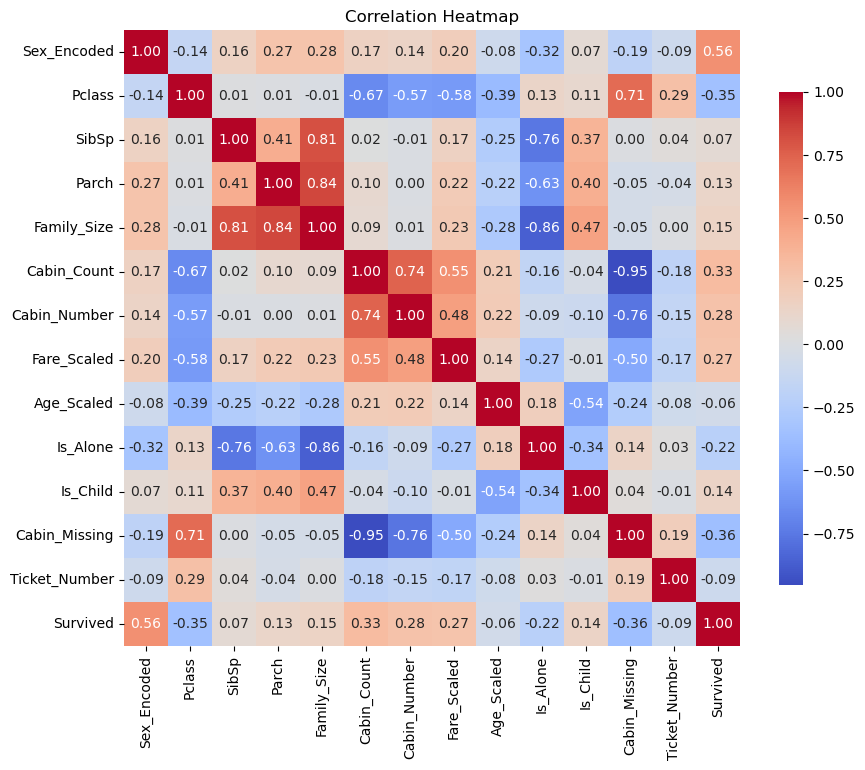

Correlation with target:
Survived         1.000000
Sex_Encoded      0.555247
Cabin_Count      0.328156
Cabin_Number     0.276457
Fare_Scaled      0.273596
Family_Size      0.147814
Is_Child         0.141876
Parch            0.128871
SibSp            0.072054
Age_Scaled      -0.061348
Ticket_Number   -0.091504
Is_Alone        -0.215281
Pclass          -0.345298
Cabin_Missing   -0.360842
Name: Survived, dtype: float64


In [273]:
correlation_matrix = plot_corr_heatmap(X_train[base_numerical_features], y_train)
correlation_with_target = correlation_matrix[target].sort_values(ascending=False)
print("Correlation with target:")
print(correlation_with_target)

In [274]:

vif_minimized_feature_list = [
    'Sex_Encoded',
    #'Cabin_Count',
    #'Fare_Scaled',
    #'Cabin_Number',
    #'Is_Child',
    #'Family_Size',
    #'Age_Scaled',
    #'Ticket_Number',
    #'Is_Alone',
    'Pclass',
    #'Parch',
    #'SibSp',
    #'Cabin_Missing'
]
    

# Check Variance Inflation Factor (VIF) of each feature
X_vif = add_constant(X_train[vif_minimized_feature_list])
X_vif = X_vif.astype(float)
vif_data = pd.DataFrame()
vif_data['Feature'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
print(vif_data)

       Feature        VIF
0        const  10.093154
1  Sex_Encoded   1.021474
2       Pclass   1.021474


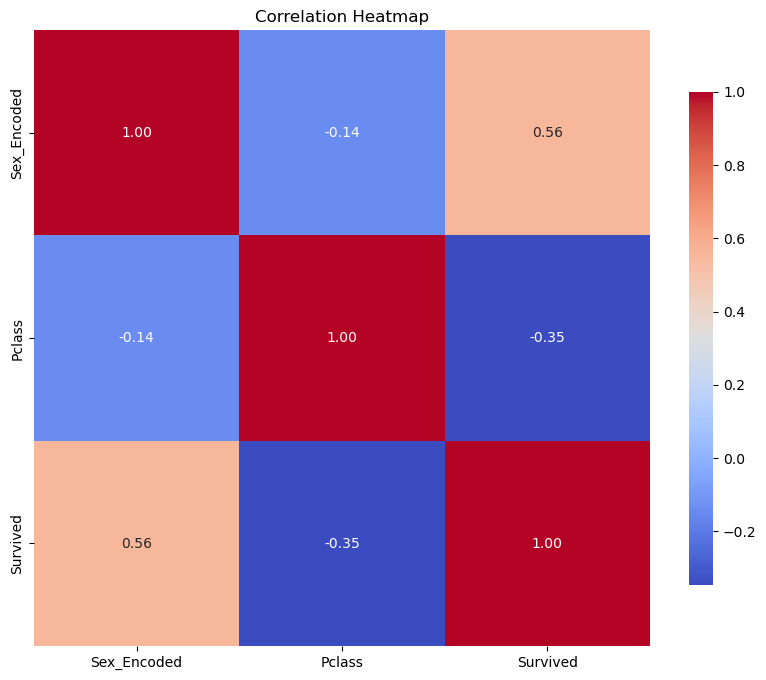

In [275]:
correlation_matrix = plot_corr_heatmap(X_train[vif_minimized_feature_list], y_train)

In [276]:
correlation_with_target = correlation_matrix[target].sort_values(ascending=False)
print("Correlation with target:")
print(correlation_with_target)

Correlation with target:
Survived       1.000000
Sex_Encoded    0.555247
Pclass        -0.345298
Name: Survived, dtype: float64


## Model Development

In [277]:
mlflow.set_tracking_uri('http://ec2-18-220-145-217.us-east-2.compute.amazonaws.com:5000/')
mlflow.set_experiment('titanic_ml_from_disaster__abridged')

<Experiment: artifact_location='s3://thoughtswork-co/mlflow/3', creation_time=1749424560671, experiment_id='3', last_update_time=1749424560671, lifecycle_stage='active', name='titanic_ml_from_disaster__abridged', tags={}>

In [278]:
def print_diagnostics(y, y_pred):
    print("\n" + "="*50)
    print("DIAGNOSTIC ANALYSIS")
    print("="*50)

    # Check class distribution
    print(f"Actual class distribution:")
    print(f"Not Survived (0): {(y == 0).sum()} ({(y == 0).mean():.1%})")
    print(f"Survived (1): {(y == 1).sum()} ({(y == 1).mean():.1%})")

    print(f"\nPredicted class distribution:")
    print(f"Not Survived (0): {(y_pred == 0).sum()} ({(y_pred == 0).mean():.1%})")
    print(f"Survived (1): {(y_pred == 1).sum()} ({(y_pred == 1).mean():.1%})")

    # Detailed classification report
    print(f"\nDetailed Classification Report:")
    print(classification_report(y, y_pred, target_names=['Not Survived', 'Survived']))

    # Confusion matrix
    print(f"\nConfusion Matrix:")
    print(confusion_matrix(y, y_pred))

### Training Set Evaluation

In [279]:
# Train and evaluate a Logistic Regression model
numerical_features_to_test = vif_minimized_feature_list

X_numerical = X_train[numerical_features_to_test]

model_params = {
    'class_weight': 'balanced', 
    'penalty': 'l1',  
    'C': 0.2,     
    'max_iter': 1000, 
    'solver': 'liblinear'
}

clf = LogisticRegression(**model_params, random_state=42)

with mlflow.start_run():
    mlflow.set_tag("dataset", "training")

    mlflow.log_params(model_params)
    mlflow.log_param("model_type", "Logistic Regression")

    print(f"\nEvaluating model with training set of {len(X_numerical)} samples:")
    print(f"Features used:")
    for i, feat in enumerate(X_numerical.columns):
        print(f"* {feat}")
        mlflow.log_param(f"feature_{i}", feat)

    clf.fit(X_numerical, y_train)

    # Predict on training set to assess bias
    y_pred = clf.predict(X_numerical)

    acc  = accuracy_score(y_train, y_pred)
    prec = precision_score(y_train, y_pred, average='macro')
    rec  = recall_score(y_train, y_pred, average='macro')
    f1   = f1_score(y_train, y_pred, average='macro')

    mlflow.log_metrics({
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1
    })

    print("\nTraining Set Scores:")
    print("Training accuracy :", acc)
    print("Training precision:", prec)
    print("Training recall   :", rec)
    print("Training F1-score :", f1)

    coef_df = pd.DataFrame(clf.coef_.T, index=X_numerical.columns, columns=['Coefficient'])
    print("\nModel Coefficients:")
    print(coef_df.sort_values(by='Coefficient', ascending=False))
    print()

    print_diagnostics(y_train, y_pred)


Evaluating model with training set of 640 samples:
Features used:
* Sex_Encoded
* Pclass

Training Set Scores:
Training accuracy : 0.7921875
Training precision: 0.7817876000681314
Training recall   : 0.7735210539912167
Training F1-score : 0.7770040685230449

Model Coefficients:
             Coefficient
Sex_Encoded     2.430613
Pclass         -0.679992


DIAGNOSTIC ANALYSIS
Actual class distribution:
Not Survived (0): 395 (61.7%)
Survived (1): 245 (38.3%)

Predicted class distribution:
Not Survived (0): 412 (64.4%)
Survived (1): 228 (35.6%)

Detailed Classification Report:
              precision    recall  f1-score   support

Not Survived       0.82      0.85      0.84       395
    Survived       0.75      0.69      0.72       245

    accuracy                           0.79       640
   macro avg       0.78      0.77      0.78       640
weighted avg       0.79      0.79      0.79       640


Confusion Matrix:
[[337  58]
 [ 75 170]]
🏃 View run monumental-hare-275 at: http://ec2-18-22

### Train-Dev Set Evaluation

In [280]:
X_train_dev = engineer_features(X_train_dev)
remove_duplicates(X_train_dev, base_categorical_features + base_numerical_features, y_train_dev)

Non-numeric Ticket Numbers in training data:
Ticket_Number
LINE    1
Name: count, dtype: int64
Number of duplicate rows in train set: 0
Number of duplicate rows in train set after dropping: 0


In [281]:
with mlflow.start_run():
    mlflow.set_tag("dataset", "train-dev")

    mlflow.log_params(model_params)
    mlflow.log_param("model_type", "Logistic Regression")

    print(f"\nEvaluating model with train-dev set of {len(X_train_dev)} samples:")
    print(f"Features used:")
    for i, feat in enumerate(numerical_features_to_test):
        print(f"* {feat}")
        mlflow.log_param(f"feature_{i}", feat)

    # Predict on train-dev set
    y_pred = clf.predict(X_train_dev[numerical_features_to_test])

    acc  = accuracy_score(y_train_dev, y_pred)
    prec = precision_score(y_train_dev, y_pred, average='macro')
    rec  = recall_score(y_train_dev, y_pred, average='macro')
    f1   = f1_score(y_train_dev, y_pred, average='macro')

    mlflow.log_metrics({
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1
    })

    print("\nTrain-Dev Set Scores:")
    print("Train-Dev accuracy :", acc)
    print("Train-Dev precision:", prec)
    print("Train-Dev recall   :", rec)
    print("Train-Dev F1-score :", f1)
    print()
    print_diagnostics(y_train_dev, y_pred)


Evaluating model with train-dev set of 72 samples:
Features used:
* Sex_Encoded
* Pclass

Train-Dev Set Scores:
Train-Dev accuracy : 0.7638888888888888
Train-Dev precision: 0.7536170212765958
Train-Dev recall   : 0.7418831168831169
Train-Dev F1-score : 0.7462160481028406


DIAGNOSTIC ANALYSIS
Actual class distribution:
Not Survived (0): 44 (61.1%)
Survived (1): 28 (38.9%)

Predicted class distribution:
Not Survived (0): 47 (65.3%)
Survived (1): 25 (34.7%)

Detailed Classification Report:
              precision    recall  f1-score   support

Not Survived       0.79      0.84      0.81        44
    Survived       0.72      0.64      0.68        28

    accuracy                           0.76        72
   macro avg       0.75      0.74      0.75        72
weighted avg       0.76      0.76      0.76        72


Confusion Matrix:
[[37  7]
 [10 18]]
🏃 View run caring-sloth-918 at: http://ec2-18-220-145-217.us-east-2.compute.amazonaws.com:5000/#/experiments/3/runs/b9d2938600634cecb1154346e

### Validation Set Evaluation

In [282]:
with mlflow.start_run():
    mlflow.set_tag("dataset", "validation")

    mlflow.log_params(model_params)
    mlflow.log_param("model_type", "Logistic Regression")

    print(f"\nEvaluating model with validation set of {len(X_numerical)} samples:")
    print(f"Features used:")
    for i, feat in enumerate(X_numerical.columns):
        print(f"* {feat}")
        mlflow.log_param(f"feature_{i}", feat)

    scoring = {
        'accuracy': 'accuracy',
        'precision': 'precision_macro', 
        'recall': 'recall_macro',
        'f1': 'f1_macro'
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_results = cross_validate(clf, X_numerical, y_train, cv=cv, scoring=scoring)

    for metric_name, scores in cv_results.items():
        if metric_name.startswith('test_'):
            mean_score = scores.mean()
            std_score = scores.std()
            print(f"CV {metric_name[5:]}: {mean_score:.4f} ± {std_score:.4f}")
            
            mlflow.log_metric(f"{metric_name[5:]}", mean_score)
            mlflow.log_metric(f"{metric_name[5:]}_std", std_score)

    print("\nCross Validation Set Scores:")
    print("Cross Validation accuracy:", cv_results['test_accuracy'].mean())
    print("Cross Validation accuracy (std):", cv_results['test_accuracy'].std())
    print("Cross Validation precision:", cv_results['test_precision'].mean())
    print("Cross Validation precision (std):", cv_results['test_precision'].std())
    print("Cross Validation recall:", cv_results['test_recall'].mean())
    print("Cross Validation recall (std):", cv_results['test_recall'].std())
    print("Cross Validation F1-score:", cv_results['test_f1'].mean())
    print("Cross Validation F1-score (std):", cv_results['test_f1'].std())


Evaluating model with validation set of 640 samples:
Features used:
* Sex_Encoded
* Pclass
CV accuracy: 0.7922 ± 0.0362
CV precision: 0.7840 ± 0.0428
CV recall: 0.7735 ± 0.0328
CV f1: 0.7773 ± 0.0362

Cross Validation Set Scores:
Cross Validation accuracy: 0.7921875
Cross Validation accuracy (std): 0.03617449032121945
Cross Validation precision: 0.7839826109733321
Cross Validation precision (std): 0.04275971136550149
Cross Validation recall: 0.7735210539912167
Cross Validation recall (std): 0.032849082500281006
Cross Validation F1-score: 0.777285070835793
Cross Validation F1-score (std): 0.03618078608144605
🏃 View run youthful-hare-337 at: http://ec2-18-220-145-217.us-east-2.compute.amazonaws.com:5000/#/experiments/3/runs/d25082a7f8cc41f995f42dd807f54128
🧪 View experiment at: http://ec2-18-220-145-217.us-east-2.compute.amazonaws.com:5000/#/experiments/3


### Test Set Evaluation

In [283]:
X_test = engineer_features(X_test)
remove_duplicates(X_test, base_categorical_features + base_numerical_features, y_test)

Non-numeric Ticket Numbers in training data:
Ticket_Number
LINE    1
Name: count, dtype: int64
Number of duplicate rows in train set: 0
Number of duplicate rows in train set after dropping: 0


In [284]:
with mlflow.start_run():
    mlflow.set_tag("dataset", "test")

    print(f"\nEvaluating model with {len(X_numerical.columns)} features:")
    for i, feat in enumerate(X_numerical.columns):
        print(f"* {feat}")
        mlflow.log_param(f"feature_{i}", feat)

    # Predict on the Test set
    y_pred = clf.predict(X_test[numerical_features_to_test])

    acc  = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred, average='macro')
    rec  = recall_score(y_val, y_pred, average='macro')
    f1   = f1_score(y_val, y_pred, average='macro')

    print("\nTest Set Scores:")
    print("Test accuracy :", acc)
    print("Test precision:", prec)
    print("Test recall   :", rec)
    print("Test F1-score :", f1)
    print()
    print_diagnostics(y_test, y_pred)

    mlflow.log_metrics({
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1
    })

# Output SHAP Summary Plot
# Ensure all data is proper numeric type
# X_train_shap = X_train[numerical_features_to_test].astype(np.float64)
# X_val_shap = X_val[numerical_features_to_test].astype(np.float64)
# explainer   = shap.LinearExplainer(clf, X_train_shap)
# shap_values = explainer.shap_values(X_val_shap)
# shap.summary_plot(
#     shap_values, X_val_shap, plot_type='dot', show=True,
#     max_display=100
# )


Evaluating model with 2 features:
* Sex_Encoded
* Pclass

Test Set Scores:
Test accuracy : 0.776536312849162
Test precision: 0.7671575437621562
Test recall   : 0.7533596837944664
Test F1-score : 0.7584345479082322


DIAGNOSTIC ANALYSIS
Actual class distribution:
Not Survived (0): 110 (61.5%)
Survived (1): 69 (38.5%)

Predicted class distribution:
Not Survived (0): 118 (65.9%)
Survived (1): 61 (34.1%)

Detailed Classification Report:
              precision    recall  f1-score   support

Not Survived       0.80      0.85      0.82       110
    Survived       0.74      0.65      0.69        69

    accuracy                           0.78       179
   macro avg       0.77      0.75      0.76       179
weighted avg       0.77      0.78      0.77       179


Confusion Matrix:
[[94 16]
 [24 45]]
🏃 View run unequaled-fly-239 at: http://ec2-18-220-145-217.us-east-2.compute.amazonaws.com:5000/#/experiments/3/runs/6101d8bf4b2a40dca5dd6a0e52ebf54b
🧪 View experiment at: http://ec2-18-220-145-217

## Submission File Generation

In [285]:
submission_test_X = pd.read_csv('./input/test.csv')

In [286]:
submission_test_X.isnull().sum().loc[lambda x: x > 0]

Age       86
Fare       1
Cabin    327
dtype: int64

In [287]:
submission_test_X[submission_test_X['Fare'].isnull()]

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
152,1044,3,"Storey, Mr. Thomas",male,60.5,0,0,3701,NaN,NaN,S


In [288]:
submission_test_X['Fare'] = submission_test_X['Fare'].fillna(submission_test_X.groupby(['Pclass', 'Embarked'])['Fare'].transform('median'))

In [289]:
submission_test_X.isnull().sum().loc[lambda x: x > 0]

Age       86
Cabin    327
dtype: int64

In [290]:
submission_test_X = engineer_features(submission_test_X)
remove_duplicates(submission_test_X, base_categorical_features + base_numerical_features)

Non-numeric Ticket Numbers in training data:
Series([], Name: count, dtype: int64)
Number of duplicate rows in train set: 1
Number of duplicate rows in train set after dropping: 0


In [291]:
submission = pd.DataFrame({
    'PassengerId': submission_test_X['PassengerId'],
    'Survived': clf.predict(submission_test_X[numerical_features_to_test])
})
timestamp = datetime.now().strftime('%Y%m%d-%H%M%S')
filename = f'./submission-{timestamp}.csv'
submission.to_csv(filename, index=False)

-----------

In [292]:
import json
import re

def slugify(text):
    text = text.strip()
    text = re.sub(r'[^\w\s\-]', '', text)  # allow (), - and alphanumerics
    return re.sub(r'[\s]+', '-', text)

def extract_headings(ipynb_path):
    with open(ipynb_path, 'r', encoding='utf-8') as f:
        nb = json.load(f)

    toc_lines = [] # ["## Table of Contents\n"]
    for cell in nb['cells']:
        if cell['cell_type'] == 'markdown':
            for line in cell['source']:
                match = re.match(r'^(#{2,6})\s+(.*)', line)
                if match:
                    level = len(match.group(1)) - 1  # offset for nesting
                    title = match.group(2).strip()
                    anchor = slugify(title)
                    indent = '    ' * (level - 1)
                    toc_lines.append(f"{indent}1. [{title}](#{anchor})")

    return '\n'.join(toc_lines)

# Example usage:
toc = extract_headings("titanic_ml_from_disaster_abridged__paultongyoo.ipynb")
print(toc)

1. [Table of Contents](#Table-of-Contents)
1. [Introduction](#Introduction)
1. [Data Understanding](#Data-Understanding)
    1. [Data Dictionary](#Data-Dictionary)
        1. [Variable Notes](#Variable-Notes)
    1. [Descriptive Statistics](#Descriptive-Statistics)
    1. [Row Samples](#Row-Samples)
    1. [Data Types](#Data-Types)
    1. [Missing Values Summary](#Missing-Values-Summary)
    1. [Sample Visual Inspection](#Sample-Visual-Inspection)
1. [Feature Engineering](#Feature-Engineering)
1. [Exploratory Data Analysis](#Exploratory-Data-Analysis)
1. [Model Development](#Model-Development)
    1. [Training Set Evaluation](#Training-Set-Evaluation)
    1. [Train-Dev Set Evaluation](#Train-Dev-Set-Evaluation)
    1. [Validation Set Evaluation](#Validation-Set-Evaluation)
    1. [Test Set Evaluation](#Test-Set-Evaluation)
1. [Submission File Generation](#Submission-File-Generation)
